In [2]:
import os
from typing import Dict
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
from diffusion_policy.common.pytorch_util import dict_apply
from diffusion_policy.common.replay_buffer import ReplayBuffer
from diffusion_policy.common.sampler import (
    SequenceSampler, get_val_mask, downsample_mask)
from diffusion_policy.model.common.normalizer import LinearNormalizer
from diffusion_policy.dataset.base_dataset import BaseImageDataset
from diffusion_policy.common.normalize_util import get_image_range_normalizer
from diffusion_policy.common.pymunk_util import ImageLightingEffect

from diffusion_policy.dataset.pusht_image_dataset import MergedPushTImageDataset

import mediapy
from robokit.debug_utils.printer import print_batch


pygame 2.1.2 (SDL 2.0.16, Python 3.9.18)
Hello from the pygame community. https://www.pygame.org/contribute.html


/mnt/dongxu-fs1/data-ssd/geyuan/programs/anaconda3/envs/robodiff/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [3]:
dataset = MergedPushTImageDataset(
    horizon=10,
    max_train_episodes=90,
    pad_after=7,
    pad_before=1,
    val_ratio=0.01,
    zarr_paths=[
        "/home/geyuan/code/dp23rss_fork/data/pusht/pusht_256.zarr",
        "/home/geyuan/code/dp23rss_fork/data/pusht/pusht_256_texture.zarr",
        # "/home/geyuan/code/dp23rss_fork/data/pusht/pusht_256_light.zarr",
        # "/home/geyuan/code/dp23rss_fork/data/pusht/pusht_256_goal.zarr",
        # "/home/geyuan/code/dp23rss_fork/data/pusht/pusht_256_block.zarr",
    ],
    shape_meta={
        "obs": {
            "image": {
                "shape": (3, 256, 256),
                "dtype": np.uint8,
            },
        },
    },
    transform_color_jitter=True,
    return_all_state=True,
)
print_batch("[DEBUG] PushTImageDataset", dataset[0])

[PushTImageDataset] Loaded from: /home/geyuan/code/dp23rss_fork/data/pusht/pusht_256.zarr, len=12394.
[PushTImageDataset] Loaded from: /home/geyuan/code/dp23rss_fork/data/pusht/pusht_256_texture.zarr, len=7192.
[MergedPushTImageDataset] Datasets merged, total length: 19586
[DEBUG] PushTImageDataset: Dict, keys=['obs', 'action', 'dataset_idx', 'local_idx']
--obs: Dict, keys=['image', 'agent_pos', 'all_state']
----image, <class 'torch.Tensor'>, shape=torch.Size([10, 3, 256, 256]), min=-1.0000, max=1.0000, dtype=torch.float32
----agent_pos, <class 'torch.Tensor'>, shape=torch.Size([10, 2]), min=-0.1186, max=0.6088, dtype=torch.float32
----all_state, <class 'torch.Tensor'>, shape=torch.Size([10, 5]), min=-1.0129, max=0.6088, dtype=torch.float32
--action, <class 'torch.Tensor'>, shape=torch.Size([10, 2]), min=-0.2812, max=0.6367, dtype=torch.float32
--dataset_idx, <class 'torch.Tensor'>, shape=torch.Size([]), value=0
--local_idx, <class 'torch.Tensor'>, shape=torch.Size([]), value=0


[DEBUG] sample: Dict, keys=['obs', 'action', 'dataset_idx', 'local_idx']
--obs: Dict, keys=['image', 'agent_pos']
----image, <class 'torch.Tensor'>, shape=torch.Size([10, 3, 256, 256]), min=-1.0000, max=1.0000, dtype=torch.float32
----agent_pos, <class 'torch.Tensor'>, shape=torch.Size([10, 2]), min=-0.0058, max=0.1710, dtype=torch.float32
--action, <class 'torch.Tensor'>, shape=torch.Size([10, 2]), min=0.0000, max=0.1562, dtype=torch.float32
--dataset_idx, <class 'torch.Tensor'>, shape=torch.Size([]), value=4
--local_idx, <class 'torch.Tensor'>, shape=torch.Size([]), value=160


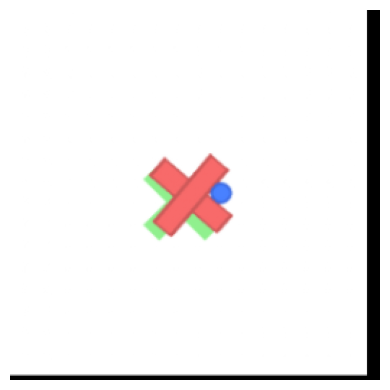

In [3]:
''' show the first single frame '''
sample = dataset[45000]
print_batch("[DEBUG] sample", sample)

img = sample["obs"]["image"][0] # (C, H, W)
img = img * 0.5 + 0.5 # unnormalize to [0, 1]
if isinstance(img, torch.Tensor):
    img = img.detach().cpu().permute(1,2,0).numpy() # (H, W, C)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
# plt.title("first frame")
plt.tight_layout()
plt.show()

''' show the first chunked frames '''
imgs = sample["obs"]["image"] # (T, C, H, W)
imgs = imgs * 0.5 + 0.5 # unnormalize to [0, 1]
if isinstance(imgs, torch.Tensor):
    imgs = imgs.detach().cpu().permute(0,2,3,1).numpy() # (T, H, W, C)
mediapy.show_video(
    imgs, fps=20,
)